# Übung

Build a model to predict Fashion MNIST
- Preparation
- Building
- Training
- Prediction
- Confusion Matrix
- Saving the model

Delivery as
1. NoteBook

## 📦 Bibliotheken importieren

In [1]:
# 📦 Standard library
# (no hay en este caso)

# 📚 Third-party
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 🃏 Own project import
# (no hay en este caso)


## 📊 Daten laden

# Define label names for Fashion MNIST classes
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Load and preprocess the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

def translate_to_names(index: int):
    return class_names[index]

## 👀 Visualize
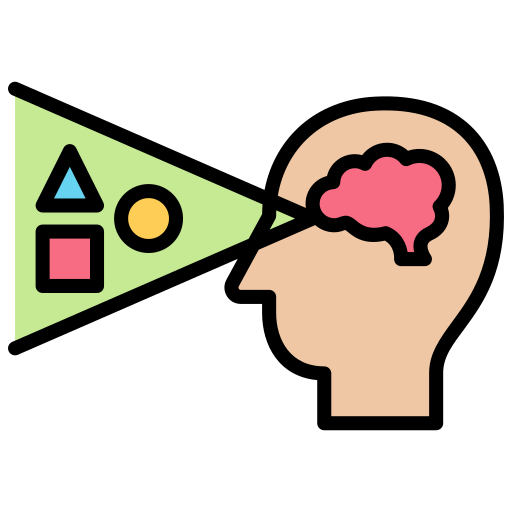

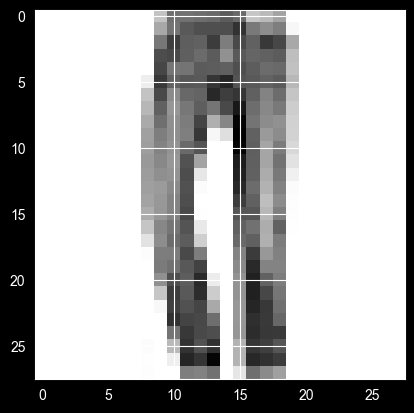

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [3]:
IMAGE_INDEX = 1500
plt.imshow(x_train[IMAGE_INDEX], cmap=plt.cm.binary)
plt.show()

y_train[IMAGE_INDEX]
x_train[12]

## 🔀 Train/Test Split

In [4]:
# Normalizar
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [5]:
# Agregar dimensión del canal
x_train = x_train.reshape(-1, 28, 28, 1)
x_train = x_train.reshape(-1, 224, 224, 3)

x_test = x_test.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 224, 224, 3)

In [6]:
# generar algo de varianza en los datos para no malacostumbrar el modelo.
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(x_train)

In [7]:
# Guardar copia de labels enteros para matriz de confusión
y_test_int = y_test.copy()

In [8]:
# One-hot para labels
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10) # y_test ya no es un entero de clase, sino un vector de 10 posiciones.

In [9]:
y_train[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [10]:
x_train[1]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.00392157],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.16078432],
        [0.7372549 ],
        [0.40392157],
        [0.21176471],
        [0.1882353 ],
        [0.16862746],
        [0.34117648],
        [0.65882355],
        [0.52156866],
        [0.0627451 ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.00392157],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.19215687],
        [0.53333336],
        [0.85882354],
        [0.84705883],
        [0.89411765],
        [0.9254902 ],
        [1.        ],
        [1.        ],
        [1.        ],
        [1.        ],
        

## ⚖️ Feature-Skalierung **(no needed here)**

In [ ]:
"""scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)"""

## 🧠 Create Modell

In [11]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),


    # Bloque 1
    layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloque 2
    layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloque 3
    layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),

    # Cabeza densa
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

## 📒 Summary

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             

 Total params: 437,098 (1.67 MB)

 Trainable params: 436,202 (1.66 MB)

 Non-trainable params: 896 (3.50 KB)

In [13]:
from keras.optimizers import SGD

optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model.compile(loss = "categorical_crossentropy", optimizer=optimizer, metrics=['accuracy'])

## 🚀 Training

In [14]:
version = model.fit(datagen.flow(x_train, y_train, batch_size=64), epochs=20, validation_data=(x_test, y_test))

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 49ms/step - accuracy: 0.7811 - loss: 0.5997 - val_accuracy: 0.8395 - val_loss: 0.4285
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 52ms/step - accuracy: 0.8492 - loss: 0.4087 - val_accuracy: 0.8727 - val_loss: 0.3520
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 59ms/step - accuracy: 0.8699 - loss: 0.3528 - val_accuracy: 0.8780 - val_loss: 0.3249
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 90s 96ms/step - accuracy: 0.8814 - loss: 0.3230 - val_accuracy: 0.8600 - val_loss: 0.3392
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 58ms/step - accuracy: 0.8884 - loss: 0.3001 - val_accuracy: 0.8773 - val_loss: 0.3333
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 59ms/step - accuracy: 0.8956 - loss: 0.2863 - val_accuracy: 0.9013 - val_loss: 0.2673
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 59ms/step - accuracy: 0.9014 - loss: 0.2704 - val_accuracy: 0.9153 - val_loss: 0.2332
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - accuracy: 0.9056 - loss: 0.2597 - 

## 📈 Plot: Accuracy & Loss

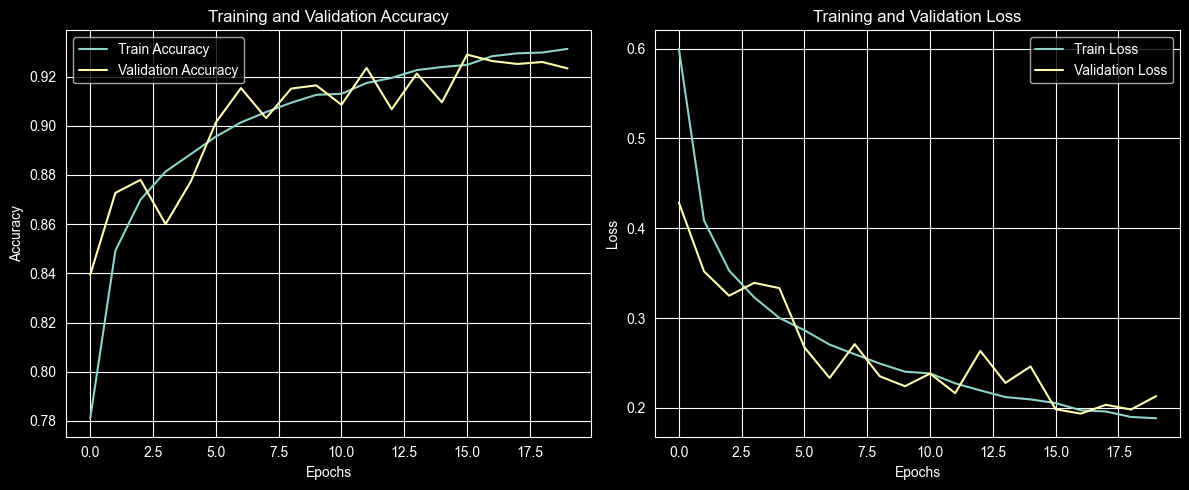

In [16]:
plt.figure(figsize=(12, 5))

# Accuracy (<-)
plt.subplot(1, 2, 1) # plt.subplot(n_filas, n_columnas, índice)
plt.plot(version.history["accuracy"], label="Train Accuracy")
plt.plot(version.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss (->)
plt.subplot(1, 2, 2)
plt.plot(version.history["loss"], label="Train Loss")
plt.plot(version.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
# Predictions
predict = model.predict(x_test)
pred_classes = np.argmax(predict, axis=1)
print("Distribución de clases predichas:", np.unique(pred_classes, return_counts=True))

# Ground truth en clases enteras
y_true = np.argmax(y_test, axis=1)
print(np.unique(y_true, return_counts=True))
print("Pred classes:", np.unique(pred_classes, return_counts=True))
print("True classes:", np.unique(y_true, return_counts=True))
print(predict[:5])


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Distribución de clases predichas: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([ 923,  988,  825, 1056,  968, 1017, 1233,  973, 1007, 1010]))
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))
Pred classes: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([ 923,  988,  825, 1056,  968, 1017, 1233,  973, 1007, 1010]))
True classes: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))
[[4.1617967e-09 8.1967872e-09 8.3956153e-10 2.4179808e-08 2.6294658e-10
  9.0675174e-05 4.3620144e-10 6.9042180e-05 1.9632695e-10 9.9984026e-01]
 [1.9647613e-04 1.0340306e-09 9.9651825e-01 2.5733591e-06 9.0700021e-05
  5.9844811e-12 3.1919414e-03 9.7569901e-14 1.1571901e-08 1.3764820e-12]
 [3.0146747e-09 1.0000000e+00 4.2585109e-11 7.3118165e-09 1.8984642e-10
  3.8738642e-14 7.8566925e-10 9.8234688e-16 4.1047948e-10 1.2818342e-13]
 [1.3025840e-07 9.9999893e

In [18]:
y_test[1]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [19]:
predict[1]

array([1.9647613e-04, 1.0340306e-09, 9.9651825e-01, 2.5733591e-06,
       9.0700021e-05, 5.9844811e-12, 3.1919414e-03, 9.7569901e-14,
       1.1571901e-08, 1.3764820e-12], dtype=float32)

## 📲 Confusion Matrix

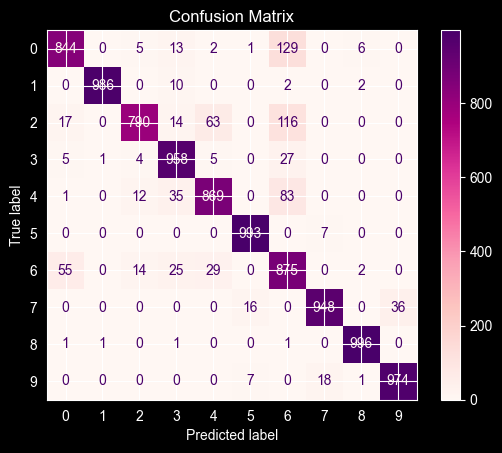

In [20]:
cm = confusion_matrix(y_test_int, pred_classes)
display = ConfusionMatrixDisplay(cm, display_labels=np.arange(10))
display.plot(cmap="RdPu", values_format="d")
plt.title("Confusion Matrix")
plt.show()


In [21]:
print("predict shape:", predict.shape)
print("primera predicción:", predict[0])
print("clase predicha primera muestra:", np.argmax(predict[0]))
print("distribución de clases predichas:", np.unique(pred_classes, return_counts=True))

predict shape: (10000, 10)
primera predicción: [4.1617967e-09 8.1967872e-09 8.3956153e-10 2.4179808e-08 2.6294658e-10
 9.0675174e-05 4.3620144e-10 6.9042180e-05 1.9632695e-10 9.9984026e-01]
clase predicha primera muestra: 9
distribución de clases predichas: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([ 923,  988,  825, 1056,  968, 1017, 1233,  973, 1007, 1010]))


## ✅ Evaluate

In [22]:
from sklearn.metrics import classification_report

eval_loss, eval_acc = model.evaluate(x_test, y_test)
f1 = classification_report(y_true, pred_classes)
print("*-*" * 10)
print(f"Accuracy: {eval_acc}")
print("*-*" * 10)
print(f"F1: {f1}")
print("*-*" * 10)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9233 - loss: 0.2130
*-**-**-**-**-**-**-**-**-**-*
Accuracy: 0.92330002784729
*-**-**-**-**-**-**-**-**-**-*
F1:               precision    recall  f1-score   support

           0       0.91      0.84      0.88      1000
           1       1.00      0.99      0.99      1000
           2       0.96      0.79      0.87      1000
           3       0.91      0.96      0.93      1000
           4       0.90      0.87      0.88      1000
           5       0.98      0.99      0.98      1000
           6       0.71      0.88      0.78      1000
           7       0.97      0.95      0.96      1000
           8       0.99      1.00      0.99      1000
           9       0.96      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.93      0.92      0.92     10000
weighted avg       0.93      0.92      0.92     10000

*-**-**-**-**-**-**-**-**-**-*


In [23]:
print(np.unique(np.argmax(y_train, axis=1), return_counts=True))
print(np.unique(pred_classes, return_counts=True))
print(x_train.shape)
print(y_train.shape)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([ 923,  988,  825, 1056,  968, 1017, 1233,  973, 1007, 1010]))
(60000, 28, 28, 1)
(60000, 10)


In [ ]:
"""indices = np.where((y_test == 0) & (pred_classes == 6))[0]
print(f"Cantidad de errores 5→3: {len(indices)}")
for i in indices[:10]:  # muestra los primeros 10
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Real: {translate_to_names(y_test[i])} | Predicted: {translate_to_names(pred_classes[i])}")
    plt.show()"""

In [ ]:
"""indices_1 = np.where((y_test == 4) & (pred_classes == 2))[0]
print(f"Cantidad de errores 4→2: {len(indices)}")
for i in indices_1[:10]:  # muestra los primeros 10
    plt.imshow(x_test[i].reshape(28, 28), cmap='grey')
    plt.title(f"Real: {translate_to_names(y_test[i])} | Predicted: {translate_to_names(pred_classes[i])}")
    plt.show()"""

# Save Model

In [24]:
model.save("fashion_model.keras")

# Load Model

In [15]:
print (nada)
model_2 = keras.models.load_model("fashion_model.keras")
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             

 Total params: 1,309,504 (5.00 MB)

 Trainable params: 436,202 (1.66 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 872,406 (3.33 MB)

# Save weights

In [ ]:
model.save_weights("fashion_model.keras.weights.h5")

In [ ]:
# crear la misma estructura del Model sin compilar ni entrenar
ACTIVATION_FUNCTION_HIDDEN_1 = 'sigmoid'
ACTIVATION_FUNCTION_HIDDEN_2 = 'relu'
ACTIVATION_FUNCTION_OUTPUT = 'softmax'

model_weights = models.Sequential([
    # 0 INPUT LAYER (primera capa -izq-)
    keras.Input(shape=(784,)),


    # 1 hidden layer (capa oculta)
    #        q tantas neuronas, que tipo de activacion,
    keras.layers.Dense(512, activation=ACTIVATION_FUNCTION_HIDDEN_1),

    # 2 hidden layer (capa oculta)
    keras.layers.Dense(128, activation=ACTIVATION_FUNCTION_HIDDEN_1),


    # 3 output layer (capa de salida)
    keras.layers.Dense(10, activation=ACTIVATION_FUNCTION_HIDDEN_1),
])


In [ ]:
# Load weights
model_weights.load_weights("fashion_model.keras.weights.h5")

# Callbacks

In [ ]:
from keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint

my_callbacks_list = [
    EarlyStopping(monitor='val_loss', min_delta=0.00001, patience=3, verbose=0, mode='auto'),
    CSVLogger('logs/fashion_training.log', append=True),
    ModelCheckpoint(filepath="./models/model.{epoch:02d}-{val_loss:.2f}.keras",)
]

# Train Model using Callbacks

In [ ]:
"""from tensorflow.keras.utils import to_categorical
history = model.fit(train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2, callbacks=my_callbacks_list)"""